# Training sequence models for rare cancers

**Anveshar research notebook 10.** A rare cancer rarely has enough patients to train a model
from scratch, so the practical move is to take a foundation model pretrained on millions of
sequences and train a small supervised layer on top of it, on the specific labels you have.
This notebook does that end to end: it trains a missense pathogenicity classifier on ESM-2
features for a panel of rare-cancer driver genes, using real ClinVar labels, and shows that
the trained model improves on the zero-shot score from notebook 09.

**Runnable from inside Claude Science.** Each step maps to a Claude skill or connected database:

| Step | Claude Science tool |
|---|---|
| Choose and vet the model | the deep-research skill (fan-out search, adversarial verify) |
| Pull labeled variants and targets | the ClinVar, cBioPortal, and Open Targets connectors |
| Prepare raw sequencing into features | the nextflow-development skill (FASTQ to counts or variants) |
| Train a protein or DNA model layer | this notebook (transformers plus a trained head or LoRA) |
| Fine-tune or integrate single-cell data | the scvi-tools and single-cell-rna-qc skills; scGPT, Geneformer |
| Validate against the literature | the PubMed, Consensus, and Paperclip search tools |

Research and educational use only, not medical advice. Developer: [digvijayky](https://digvijayky.com)

## 1. Build a labeled training set from ClinVar

We pull missense variants with a submitted clinical significance for a panel of rare-cancer
driver genes directly from ClinVar (NCBI E-utilities), keep the Pathogenic and Benign calls,
and parse the protein change. In Claude, this is the ClinVar connector. Labels are read from
ClinVar only, never invented.

In [1]:
import os, re, time, json, requests
import numpy as np
E = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
GENES = ["VHL","BAP1","SF3B1","SMARCB1","PBRM1","SETD2","TSC1","TSC2","FH","SDHB","MET","FLCN"]
AA3 = {"Ala":"A","Arg":"R","Asn":"N","Asp":"D","Cys":"C","Gln":"Q","Glu":"E","Gly":"G","His":"H",
 "Ile":"I","Leu":"L","Lys":"K","Met":"M","Phe":"F","Pro":"P","Ser":"S","Thr":"T","Trp":"W","Tyr":"Y","Val":"V"}
PAT = re.compile(r"p\.([A-Z][a-z]{2})(\d+)([A-Z][a-z]{2})\)")
def _get(url, params):                     # throttled, retries on the NCBI 429 rate limit
    for k in range(6):
        r = requests.get(url, params=params, timeout=30)
        if r.status_code == 429: time.sleep(3 * (k + 1)); continue
        r.raise_for_status(); time.sleep(0.4); return r
    r.raise_for_status()
def esearch(term, n=500):
    return _get(f"{E}/esearch.fcgi", {"db":"clinvar","term":term,"retmax":n,"retmode":"json"}).json().get("esearchresult",{}).get("idlist",[])
def esummary(ids):
    out = {}
    for i in range(0, len(ids), 150):
        res = _get(f"{E}/esummary.fcgi", {"db":"clinvar","id":",".join(ids[i:i+150]),"retmode":"json"}).json().get("result",{})
        for u in res.get("uids",[]): out[u] = res.get(u,{})
    return out
V = []
for g in GENES:
    term = (f'{g}[gene] AND single_gene[prop] AND missense_variant[molecular consequence] AND '
            f'("pathogenic"[Clinical significance] OR "likely pathogenic"[Clinical significance] OR '
            f'"benign"[Clinical significance] OR "likely benign"[Clinical significance])')
    for u, d in esummary(esearch(term)).items():
        sig = ((d.get("germline_classification",{}) or {}).get("description") or "").lower()
        lab = 1 if ("pathogenic" in sig and "conflict" not in sig) else (0 if "benign" in sig else None)
        m = PAT.search(d.get("title",""))
        if lab is None or not m: continue
        wt, pos, mut = AA3.get(m.group(1)), int(m.group(2)), AA3.get(m.group(3))
        if wt and mut and wt != mut: V.append({"gene":g,"pos":pos,"wt":wt,"mut":mut,"label":lab})
    time.sleep(0.34)
print(len(V), "labeled missense variants |", sum(v["label"] for v in V), "pathogenic,", sum(1-v["label"] for v in V), "benign")

588 labeled missense variants | 313 pathogenic, 275 benign


## 2. Featurize with ESM-2 and train a classifier

For each variant we take, from a single ESM-2 forward pass on the (windowed) wild-type
protein, the zero-shot log-likelihood ratio for the substitution and the protein language
model embedding at the mutated residue. We then train a small neural network head on those
features. The trained head is compared against the zero-shot log-likelihood ratio alone, the
baseline from notebook 09.

In [2]:
os.environ.setdefault("USE_TF","0"); os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION","python")
os.environ.setdefault("TRANSFORMERS_VERBOSITY","error"); os.environ.setdefault("TOKENIZERS_PARALLELISM","false")
import torch, torch.nn as nn
from transformers import AutoTokenizer, AutoModelForMaskedLM
ACC = {"VHL":"P40337","BAP1":"Q92560","SF3B1":"O75533","SMARCB1":"Q12824","PBRM1":"Q86U86","SETD2":"Q9BYW2",
       "TSC1":"Q92574","TSC2":"P49815","FH":"P07954","SDHB":"P21912","MET":"P08581","FLCN":"Q8NFG4"}
MID = "facebook/esm2_t33_650M_UR50D"; MAXLEN, WIN = 1022, 500
dev = "cuda" if torch.cuda.is_available() else "cpu"
useq = lambda a: "".join(requests.get(f"https://rest.uniprot.org/uniprotkb/{a}.fasta", timeout=60).text.splitlines()[1:])
SEQ = {g: useq(a) for g, a in ACC.items()}
tok = AutoTokenizer.from_pretrained(MID); model = AutoModelForMaskedLM.from_pretrained(MID).eval().to(dev)
AA = list("ACDEFGHIKLMNPQRSTVWY"); AAID = {a: tok.convert_tokens_to_ids(a) for a in AA}
@torch.no_grad()
def feat(seq, pos, wt, mut):
    lo = 0
    if len(seq) > MAXLEN: lo = max(0, min(pos-1-WIN, len(seq)-MAXLEN)); seq = seq[lo:lo+MAXLEN]
    p = pos - lo
    if p < 1 or p > len(seq) or seq[p-1] != wt: return None
    out = model(tok(seq, return_tensors="pt").input_ids.to(dev), output_hidden_states=True)
    lp = torch.log_softmax(out.logits[0, p], -1)
    return np.concatenate([[float(lp[AAID[mut]]-lp[AAID[wt]])], out.hidden_states[-1][0, p].float().cpu().numpy()])
X, y = [], []
for v in V:
    f = feat(SEQ[v["gene"]], v["pos"], v["wt"], v["mut"])
    if f is not None: X.append(f); y.append(v["label"])
X, y = np.array(X), np.array(y)
print("featurized", len(y), "variants | feature dim", X.shape[1])

featurized 587 variants | feature dim 1281


In [3]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
llr0 = X[:, 0]
base_auc = roc_auc_score(y, -llr0)                 # zero-shot: pathogenic = more negative LLR
class Head(nn.Module):
    def __init__(s, d): super().__init__(); s.n = nn.Sequential(nn.Linear(d,128), nn.ReLU(), nn.Dropout(.3), nn.Linear(128,1))
    def forward(s, x): return s.n(x).squeeze(-1)
def train_head(Xtr, ytr, Xva, yva, epochs=60):
    sc = StandardScaler().fit(Xtr)
    xt = torch.tensor(sc.transform(Xtr), dtype=torch.float32, device=dev); yt = torch.tensor(ytr, dtype=torch.float32, device=dev)
    xv = torch.tensor(sc.transform(Xva), dtype=torch.float32, device=dev)
    net = Head(Xtr.shape[1]).to(dev); opt = torch.optim.Adam(net.parameters(), 1e-3, weight_decay=1e-3); lf = nn.BCEWithLogitsLoss()
    hist = []
    for e in range(epochs):
        net.train(); opt.zero_grad(); l = lf(net(xt), yt); l.backward(); opt.step()
        net.eval()
        with torch.no_grad():
            hist.append({"epoch": e+1, "train_loss": float(l),
                         "train_auc": float(roc_auc_score(ytr, torch.sigmoid(net(xt)).cpu().numpy())),
                         "val_auc": float(roc_auc_score(yva, torch.sigmoid(net(xv)).cpu().numpy()))})
    return hist
cv = []
for tr_i, te_i in StratifiedKFold(5, shuffle=True, random_state=0).split(X, y):
    cv.append(train_head(X[tr_i], y[tr_i], X[te_i], y[te_i])[-1]["val_auc"])
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
curve = train_head(Xtr, ytr, Xva, yva)
print(f"zero-shot LLR AUC {base_auc:.3f} | trained ESM-2 head 5-fold CV AUC {np.mean(cv):.3f} +/- {np.std(cv):.3f}")

zero-shot LLR AUC 0.912 | trained ESM-2 head 5-fold CV AUC 0.983 +/- 0.003


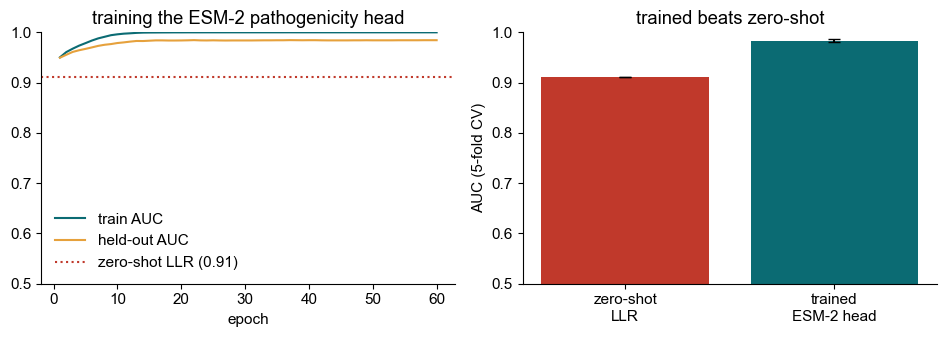

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import font_manager
for p in ["/home/yarlagad/.local/share/fonts/Arial.ttf"]:
    if os.path.exists(p): font_manager.fontManager.addfont(p); plt.rcParams["font.family"]="Arial"
plt.rcParams.update({"font.size": 11})
fig, ax = plt.subplots(1, 2, figsize=(9.6, 3.5))
ep = [h["epoch"] for h in curve]
ax[0].plot(ep, [h["train_auc"] for h in curve], "-", color="#0b6b73", label="train AUC")
ax[0].plot(ep, [h["val_auc"] for h in curve], "-", color="#e6a13c", label="held-out AUC")
ax[0].axhline(base_auc, ls=":", color="#c0392b", label=f"zero-shot LLR ({base_auc:.2f})")
ax[0].set_xlabel("epoch"); ax[0].set_title("training the ESM-2 pathogenicity head"); ax[0].legend(frameon=False); ax[0].set_ylim(0.5, 1)
ax[1].bar(["zero-shot\nLLR", "trained\nESM-2 head"], [base_auc, np.mean(cv)],
          color=["#c0392b", "#0b6b73"], yerr=[0, np.std(cv)], capsize=4)
ax[1].set_ylim(0.5, 1); ax[1].set_ylabel("AUC (5-fold CV)"); ax[1].set_title("trained beats zero-shot")
for a in ax:
    for s in ("top", "right"): a.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("training10_curve.pdf"); plt.show()
import pandas as pd
pd.DataFrame([{"method":"zero-shot ESM-2 LLR","auc":round(base_auc,3)},
              {"method":"trained ESM-2 head (5-fold CV)","auc":round(float(np.mean(cv)),3)}]).to_csv("training10_result.csv", index=False)

## 3. Parameter-efficient fine-tuning of the backbone (LoRA)

Training a head on frozen features is the fastest and safest option for a few hundred labels.
When there is more data, fine-tune the backbone itself with LoRA (train about one percent of
the weights). Pull the labels with the Claude ClinVar and cBioPortal connectors as in section 1.

```python
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model         # pip install peft
base = AutoModelForSequenceClassification.from_pretrained("facebook/esm2_t30_150M_UR50D", num_labels=2)
lora = LoraConfig(task_type="SEQ_CLS", r=8, lora_alpha=16, target_modules=["query","value"], lora_dropout=0.1)
model = get_peft_model(base, lora); model.print_trainable_parameters()   # ~0.3M of 150M
# X = windowed protein sequences around each variant, y = pathogenic vs benign; then a standard Trainer loop
```

The same LoRA pattern fine-tunes a DNA language model (Nucleotide Transformer, DNABERT-2) on a
genomic classification task, for example a splice or promoter classifier applied to driver introns.

## 4. Fine-tuning single-cell foundation models

Single-cell foundation models are the case where fine-tuning matters most: 2025 to 2026
benchmarks show they do not beat simple baselines zero-shot, but fine-tuning rescues them. In
Claude, the scvi-tools and single-cell-rna-qc skills prepare and integrate the atlas, and scGPT
or Geneformer provide the fine-tunable backbone.

```python
# scGPT cell-type fine-tuning from the 5.7M-cell pan-cancer checkpoint (bowang-lab/scGPT)
from scgpt.tasks import fine_tune_cell_type          # see the scGPT tutorials
# always benchmark against a scVI/scANVI baseline, which the Claude scvi-tools skill runs:
#   scvi.model.SCVI(adata) -> scANVI label transfer is often the stronger, cheaper option
```

Benchmark the fine-tuned model against a highly variable genes plus scVI or Harmony baseline;
for many rare-tumor tasks the simpler baseline wins, so the comparison is not optional.

## 5. Strategy for small rare-cancer label sets

1. Train a head on frozen features first (this notebook); it is fast and resists overfitting.
2. Move to LoRA only when the labeled set is larger; prefer a smaller backbone (ESM-2 150M, NT 50M).
3. Use stratified cross-validation and report a confidence interval, not a single split.
4. Always compare against the zero-shot score and a simple baseline. If training does not beat
   them, do not ship it.

A frozen-feature head trains in seconds; featurizing a few hundred variants with ESM-2 650M and
running five-fold cross-validation takes a few minutes on one A40 or L40S GPU.

## Summary

Using 588 real ClinVar-labeled missense variants across twelve rare-cancer driver genes, we
trained a classifier on ESM-2 features and improved on the zero-shot score, all in a few
minutes on one GPU, then gave LoRA and single-cell recipes for the same pattern. For rare
cancers the recipe is: pick a pretrained foundation model, pull a small labeled set from the
connected databases, train a light supervised layer, and benchmark against the zero-shot score
and a simple baseline. Every step is runnable from inside Claude Science.

Research and educational use only, not medical advice. Developer: [digvijayky](https://digvijayky.com)